In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from pathlib import Path

In [ ]:
# Clone repo if it is not already present
repo_url = "https://github.com/ccg-esb-lab/vip205.git"
repo_name = "vip205"

if not Path(repo_name).exists():
    !git clone {repo_url}

REPO_ROOT = Path(repo_name).resolve()
print("Repo root:", REPO_ROOT)



In [ ]:
pathCSV    = REPO_ROOT / 'data/cytometry/'

# List of file names
csv_files = ['exp1_cytometry_VIP.csv', 'exp2_cytometry_VIP.csv', 'exp3_cytometry_VIP.csv']

# Load all files into a list of DataFrames
df_list = []
for file in csv_files:
    file_path = os.path.join(pathCSV, file)
    df = pd.read_csv(file_path)
    df_list.append(df)

# Combine all data into a single DataFrame
df_combined = pd.concat(df_list, ignore_index=True)

# Display basic info
print("[INFO] Data successfully loaded!")


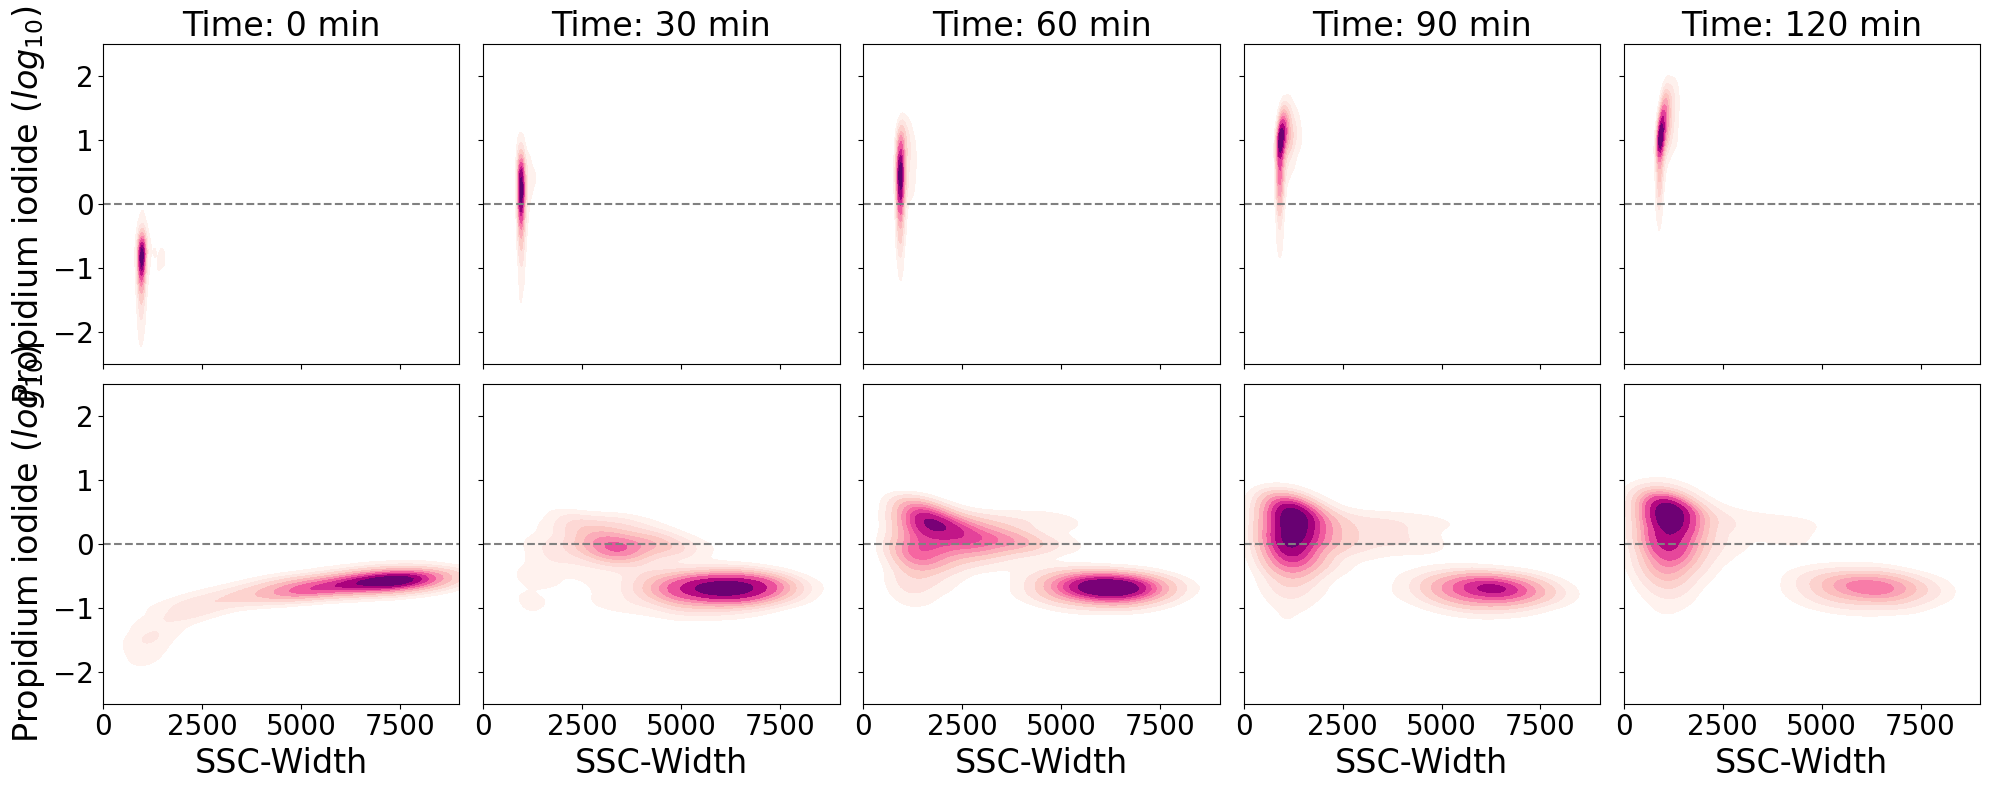

In [4]:

# Filter dataset for experiment 3 and make a copy
df_exp3 = df_combined[df_combined['experiment'] == 'exp3'].copy()

# Ensure correct data types
df_exp3['time'] = df_exp3['time'].astype(int)

# Define unique time points and states
time_points = sorted(df_exp3['time'].unique())
states = ["VIP205+IPTG", "VIP205"]

# Create the figure with two rows (states) and columns for unique time points
fig, axes = plt.subplots(nrows=2, ncols=len(time_points), figsize=(len(time_points) * 4, 8), sharex=True, sharey=True)

# Iterate over states and time points to create subplots
for row_idx, state in enumerate(states):
    for col_idx, time in enumerate(time_points):
        ax = axes[row_idx, col_idx]

        # Filter data for current state and time point
        subset = df_exp3[(df_exp3['state'] == state) & (df_exp3['time'] == time)]

        # Plot density instead of scatter points
        sns.kdeplot(data=subset, x="cell_length", y="propidium_iodide", fill=True, thresh=0.1, levels=10, cmap="RdPu", ax=ax)

        # Titles and labels
        if row_idx == 0:
            ax.set_title(f"Time: {time} min", fontsize=24)
        if col_idx == 0:
            ax.set_ylabel(r"Propidium iodide ($log_{10}$)", fontsize=24)
        else:
            ax.set_ylabel("")

        ax.set_ylim([-2.5, 2.5])
        ax.set_xlim([0, 9e3])
        ax.set_xlabel("SSC-Width", fontsize=24)
        ax.tick_params(labelsize=20)
        ax.axhline(0, linestyle="--", color="gray", linewidth=1.5)


# Adjust layout
plt.tight_layout()
plt.show()


## $\Delta$ RecA


In [8]:

csv_urls = [
    "https://zenodo.org/records/19239574/files/VIP205_VIPdeltaRecA.csv?download=1"
]

df_list = [pd.read_csv(url) for url in csv_urls]
df_combined = pd.concat(df_list, ignore_index=True)

print("[INFO] Data successfully loaded!")
print(df_combined.head())

[INFO] Data successfully loaded!
   strain            stress   IPTG  time  rep  propidium_iodide_log10 state  \
0  VIP205  heat shock(90°C)  IPTG+   240    1               -1.214570  dead   
1  VIP205  heat shock(90°C)  IPTG+   240    1               -1.552249  dead   
2  VIP205  heat shock(90°C)  IPTG+   240    1               -1.372828  dead   
3  VIP205  heat shock(90°C)  IPTG+   240    1               -1.431373  dead   
4  VIP205  heat shock(90°C)  IPTG+   240    1               -1.371435  dead   

     size    SSC-Width        FL2-A          SSC-A  
0  normal   778.178223  3013.500000   49390.300781  
1  normal   707.791931  1135.699951   40505.398438  
2  normal   726.422302  2073.300049   48920.398438  
3  normal  1105.538086  5500.399902  148514.000000  
4  normal   763.491577  2520.100098   59272.500000  


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_kde_distributions_by_time(df, stress_condition, time_points=None):
    """
    Plots density distributions of SSC-Width vs. log10(PI) for a given stress condition,
    comparing IPTG- and IPTG+ across selected time points.

    Parameters:
    - df (pd.DataFrame): Input dataframe with columns ['stress', 'IPTG', 'time', 'SSC-Width', 'propidium_iodide_log10']
    - stress_condition (str): Stress condition to filter (e.g., 'AMP', 'Cd', 'no stress')
    - time_points (list of int): Optional list of time points to plot. If None, plots all time points found in the data.
    """

    # Set color map depending on stress condition
    colormap = {
        'AMP': 'RdPu',
        'Cd': 'Oranges',
        'no stress': 'Greys'
    }.get(stress_condition, 'viridis')  # default to 'viridis' if stress not listed

    # Filter the data
    df_exp = df[df['stress'] == stress_condition].copy()
    df_exp['time'] = df_exp['time'].astype(int)

    # Get time points
    if time_points is None:
        time_points = sorted(df_exp['time'].unique())

    states = ["IPTG-", "IPTG+"]

    # Create figure
    fig, axes = plt.subplots(nrows=2, ncols=len(time_points),
                             figsize=(len(time_points) * 4, 8),
                             sharex=True, sharey=True)

    # Iterate through states and time points
    for row_idx, state in enumerate(states):
        for col_idx, time in enumerate(time_points):
            ax = axes[row_idx, col_idx]

            subset = df_exp[(df_exp['IPTG'] == state) & (df_exp['time'] == time)]

            if not subset.empty:
                sns.kdeplot(
                    data=subset,
                    x="SSC-Width",
                    y="propidium_iodide_log10",
                    fill=True,
                    thresh=0.1,
                    levels=10,
                    cmap=colormap,
                    ax=ax
                )

            # Titles and labels
            if row_idx == 0:
                ax.set_title(f"Time: {time} min", fontsize=20)
            if col_idx == 0:
                ax.set_ylabel(r"PI ($\log_{10}$)", fontsize=18)
            else:
                ax.set_ylabel("")

            if row_idx == 1:
                ax.set_xlabel("SSC-Width", fontsize=18)
            else:
                ax.set_xlabel("")

            ax.tick_params(labelsize=14)
            ax.axhline(0, linestyle="--", color="gray", linewidth=1.5)
            ax.set_xlim([0, 10000])
            ax.set_ylim([-5, 2.5])

    fig.suptitle(f"{stress_condition} — SSC vs. PI Distributions", fontsize=22)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

#plot_kde_distributions_by_time(df_combined, stress_condition='AMP', time_points=[0, 120, 240])
#plot_kde_distributions_by_time(df_combined, stress_condition='Cd')


### Survival fraction

AMP IPTG+    time   IPTG  PI_positive_fraction
0     0  IPTG+              1.926914
2   120  IPTG+              4.007942
4   240  IPTG+             83.741641
AMP IPTG-    time   IPTG  PI_positive_fraction
1     0  IPTG-              3.293050
3   120  IPTG-              9.246804
5   240  IPTG-             60.507129


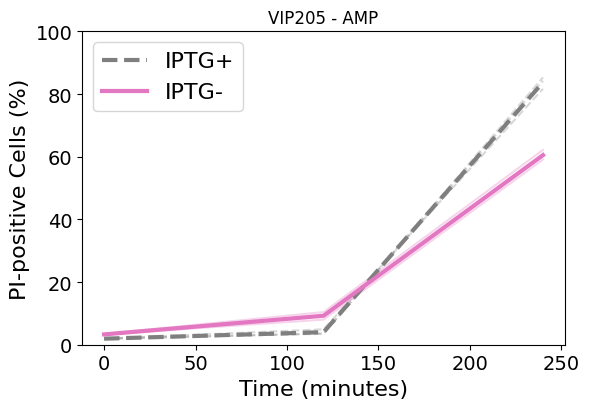

Cd IPTG+    time   IPTG  PI_positive_fraction
0     0  IPTG+              3.608899
2   120  IPTG+             51.401948
4   240  IPTG+             62.778675
Cd IPTG-    time   IPTG  PI_positive_fraction
1     0  IPTG-              3.811949
3   120  IPTG-             16.409470
5   240  IPTG-             35.019895


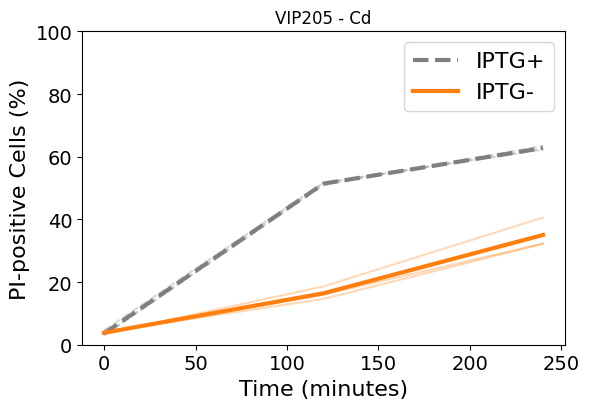

no stress IPTG+    time   IPTG  PI_positive_fraction
0     0  IPTG+              2.159842
2   120  IPTG+              1.523097
4   240  IPTG+              3.562816
no stress IPTG-    time   IPTG  PI_positive_fraction
1     0  IPTG-              2.850922
3   120  IPTG-              1.119739
5   240  IPTG-              1.387099


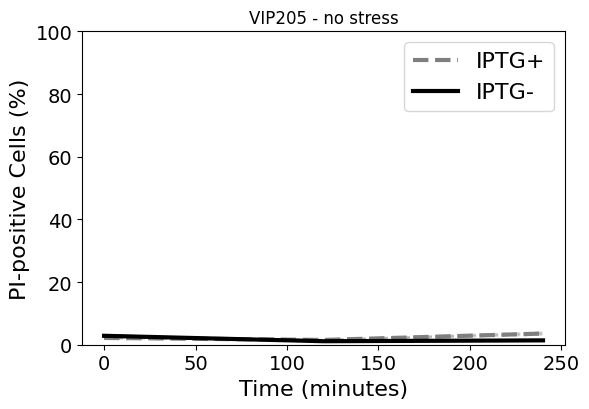

AMP IPTG+    time   IPTG  PI_positive_fraction
0     0  IPTG+              2.012993
2   120  IPTG+             57.257308
4   240  IPTG+             48.331149
AMP IPTG-    time   IPTG  PI_positive_fraction
1     0  IPTG-              4.293210
3   120  IPTG-              7.857121
5   240  IPTG-             10.985597


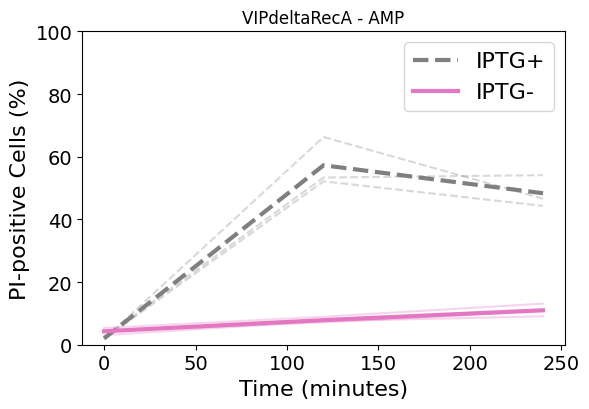

Cd IPTG+    time   IPTG  PI_positive_fraction
0     0  IPTG+              4.832265
2   120  IPTG+             40.295770
4   240  IPTG+             47.958398
Cd IPTG-    time   IPTG  PI_positive_fraction
1     0  IPTG-              3.551807
3   120  IPTG-              6.465400
5   240  IPTG-              9.356067


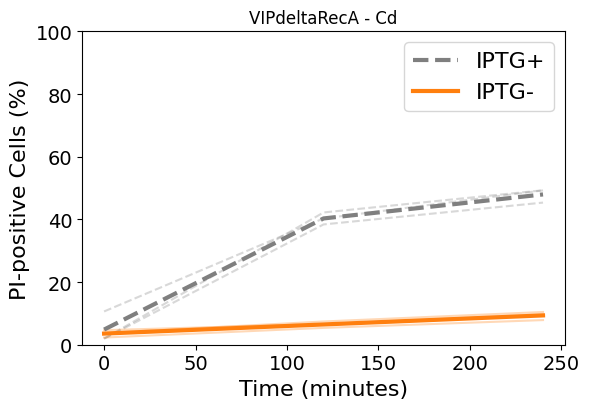

no stress IPTG+    time   IPTG  PI_positive_fraction
0     0  IPTG+              1.737873
2   120  IPTG+              2.803560
4   240  IPTG+              3.484965
no stress IPTG-    time   IPTG  PI_positive_fraction
1     0  IPTG-              3.514546
3   120  IPTG-              5.587635
5   240  IPTG-              4.168986


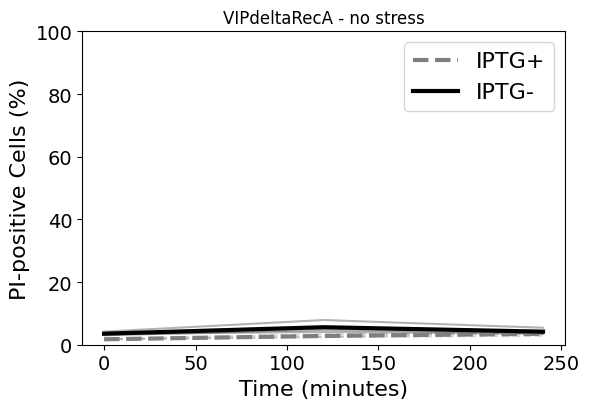

In [10]:

def plot_pi_positive_fraction(df, this_strain, stress_condition):
    """
    Plots the percentage of PI-positive cells over time for a given stress condition.

    Parameters:
    - df (pd.DataFrame): DataFrame with columns 'strain', 'stress', 'IPTG', 'time', 'rep', 'state'.
    - this_strain (str): Strain to filter (e.g., 'VIP205').
    - stress_condition (str): The stress condition to filter for (e.g., 'AMP', 'Cd', 'no stress').
    """
    # Filter for the selected strain and stress condition
    df_strain = df[df['strain'] == this_strain].copy()
    df_exp = df_strain[df_strain['stress'] == stress_condition].copy()
    df_exp['time'] = df_exp['time'].astype(int)

    # Compute the fraction of dead cells per time point, IPTG, and replicate
    df_pi_fraction = (
        df_exp.groupby(['time', 'stress', 'IPTG', 'rep'])['state']
        .apply(lambda x: (x == 'dead').mean())
        .reset_index(name='PI_positive_fraction')
    )

    # Convert fraction to percentage
    df_pi_fraction['PI_positive_fraction'] *= 100

    # Dynamic color palette
    if stress_condition == "AMP":
        palette = {'IPTG+': 'tab:grey', 'IPTG-': 'tab:pink'}
    elif stress_condition == "Cd":
        palette = {'IPTG+': 'tab:grey', 'IPTG-': 'tab:orange'}
    else:
        palette = {'IPTG+': 'tab:grey', 'IPTG-': 'black'}

    # Plot setup
    plt.figure(figsize=(6, 4.2))

    # Plot each replicate in light color
    for (state, rep), subset in df_pi_fraction.groupby(['IPTG', 'rep']):
        linestyle = "--" if state == "IPTG+" else "-"
        sns.lineplot(data=subset, x="time", y="PI_positive_fraction",
                     color=palette.get(state, 'tab:blue'), linestyle=linestyle, alpha=0.3)

    # Compute and plot mean over replicates
    df_pi_mean = df_pi_fraction.groupby(['time', 'IPTG'])['PI_positive_fraction'].mean().reset_index()
    for state in df_pi_mean['IPTG'].unique():
        subset = df_pi_mean[df_pi_mean['IPTG'] == state]
        linestyle = "--" if state == "IPTG+" else "-"
        print(stress_condition, state, subset)
        sns.lineplot(data=subset, x="time", y="PI_positive_fraction",
                     color=palette.get(state, 'tab:blue'), linestyle=linestyle, linewidth=3, label=state)

    # Labeling
    plt.xlabel("Time (minutes)", fontsize=16)
    plt.ylabel("PI-positive Cells (%)", fontsize=16)
    plt.title(f"{this_strain} - {stress_condition}")
    plt.legend(fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.ylim([0, 100])
    plt.tight_layout()
    plt.show()



this_strain='VIP205'
plot_pi_positive_fraction(df_combined, this_strain, 'AMP')
plot_pi_positive_fraction(df_combined, this_strain, 'Cd')
plot_pi_positive_fraction(df_combined, this_strain, 'no stress')


this_strain='VIPdeltaRecA'
plot_pi_positive_fraction(df_combined, this_strain, 'AMP')
plot_pi_positive_fraction(df_combined, this_strain, 'Cd')
plot_pi_positive_fraction(df_combined, this_strain, 'no stress')


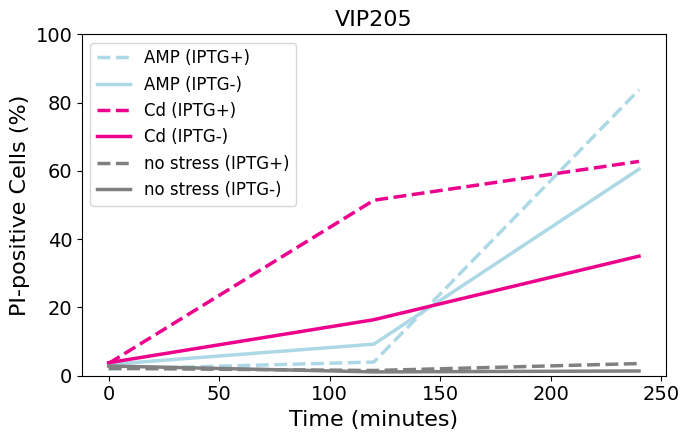

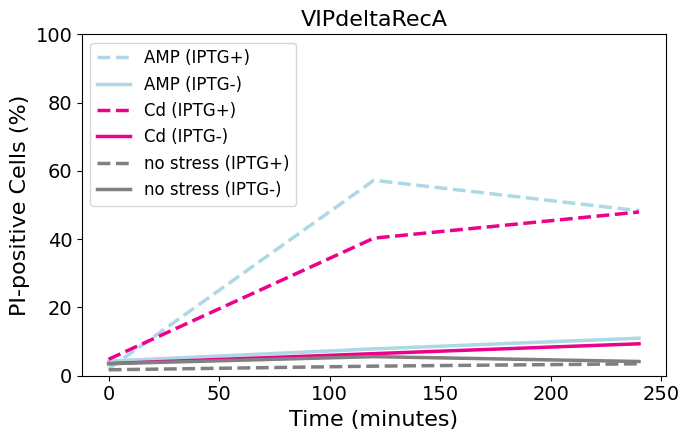

In [11]:
def plot_combined_pi_positive_fraction(df, this_strain, stress_conditions):
    """
    Plots the percentage of PI-positive cells over time for multiple stress conditions in the same plot.

    Parameters:
    - df (pd.DataFrame): Input dataframe.
    - this_strain (str): Strain to filter.
    - stress_conditions (list of str): List of stress conditions to plot (e.g., ['AMP', 'Cd', 'no stress']).
    """
    # Color map for each stress + IPTG status
    base_palette = {
        'AMP': '#ADD8E6',
        'Cd': '#EC008C',
        'no stress': 'grey'
    }

    df_strain = df[df['strain'] == this_strain].copy()
    df_strain['time'] = df_strain['time'].astype(int)

    plt.figure(figsize=(7, 4.5))

    for stress in stress_conditions:
        df_exp = df_strain[df_strain['stress'] == stress].copy()

        # Compute dead cell fraction
        df_pi_fraction = (
            df_exp.groupby(['time', 'IPTG', 'rep'])['state']
            .apply(lambda x: (x == 'dead').mean())
            .reset_index(name='PI_positive_fraction')
        )
        df_pi_fraction['PI_positive_fraction'] *= 100

        # Mean across replicates
        df_mean = (
            df_pi_fraction.groupby(['time', 'IPTG'])['PI_positive_fraction']
            .mean()
            .reset_index()
        )

        for state in ['IPTG+', 'IPTG-']:
            linestyle = "--" if state == "IPTG+" else "-"
            subset = df_mean[df_mean['IPTG'] == state]
            label = f"{stress} ({state})"
            color = base_palette.get(stress, 'tab:blue') if state == 'IPTG+' else base_palette.get(stress, 'tab:blue')

            sns.lineplot(data=subset, x="time", y="PI_positive_fraction",
                         label=label, linestyle=linestyle, color=color, linewidth=2.5)

    # Labels and layout
    plt.xlabel("Time (minutes)", fontsize=16)
    plt.ylabel("PI-positive Cells (%)", fontsize=16)
    plt.ylim([0, 100])
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=12)
    plt.title(this_strain, fontsize=16)
    plt.tight_layout()
    plt.show()
plot_combined_pi_positive_fraction(df_combined, 'VIP205', ['AMP', 'Cd', 'no stress'])

plot_combined_pi_positive_fraction(df_combined, 'VIPdeltaRecA', ['AMP', 'Cd', 'no stress'])

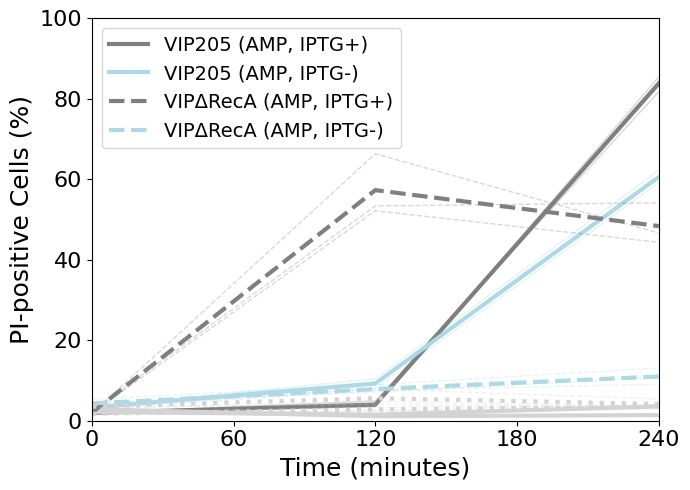

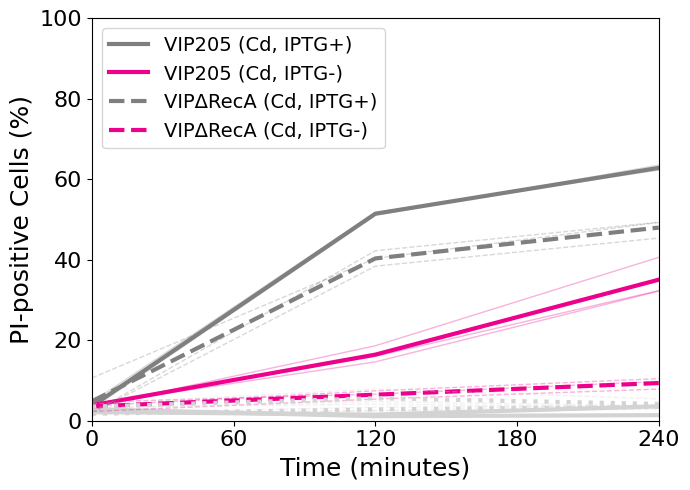

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_pi_positive_fraction_with_control(df, strains, stress_conditions):
    """
    Plots the percentage of PI-positive cells over time for selected stress conditions
    along with the no-stress control. Colors represent stress; line style represents strain.
    IPTG+ is always grey. IPTG- uses stress-specific color (black for no stress).
    """

    stress_colors = {
        'AMP': '#ADD8E6',      # Light blue
        'Cd': '#EC008C',       # Magenta
        'no stress': 'grey'
    }

    df = df.copy()
    df['time'] = df['time'].astype(int)

    for stress in stress_conditions:
        plt.figure(figsize=(7, 5))
        for strain in strains:
            for condition in [stress, 'no stress']:
                df_subset = df[(df['strain'] == strain) & (df['stress'] == condition)].copy()

                # Compute PI-positive fraction
                df_pi = (
                    df_subset.groupby(['time', 'IPTG', 'rep'])['state']
                    .apply(lambda x: (x == 'dead').mean())
                    .reset_index(name='PI_positive_fraction')
                )
                df_pi['PI_positive_fraction'] *= 100

                # Mean over replicates
                df_mean = (
                    df_pi.groupby(['time', 'IPTG'])['PI_positive_fraction']
                    .mean()
                    .reset_index()
                )

                # Plot each replicate in light color
                for (iptg, rep), subrep in df_pi.groupby(['IPTG', 'rep']):
                    linestyle = '--' if 'delta' in strain and iptg == 'IPTG+' else (
                                '-' if iptg == 'IPTG+' else (
                                '--' if 'delta' in strain else '-'))
                    color = 'lightgrey' if condition == 'no stress' else (
                            'tab:grey' if iptg == 'IPTG+' else stress_colors.get(condition, 'black'))

                    sns.lineplot(data=subrep, x="time", y="PI_positive_fraction",
                                color=color, linestyle=linestyle, alpha=0.3, linewidth=1)


                for iptg in df_mean['IPTG'].unique():

                    if iptg == 'IPTG+':
                      if 'no stress' in condition:
                        linestyle = ':' if 'delta' in strain else '-'
                        color = 'lightgrey'
                        label = ""
                      else:
                        linestyle = '--' if 'delta' in strain else '-'
                        color = 'tab:grey'
                        label = f"{strain.replace('delta', 'Δ')} ({condition}, {iptg})"

                    else:

                      if 'no stress' in condition:
                        linestyle = ':' if 'delta' in strain else '-'
                        color = 'lightgrey'
                        label = ""
                      else:
                        linestyle = '--' if 'delta' in strain else '-'
                        color = stress_colors.get(condition, 'tab:black')
                        label = f"{strain.replace('delta', 'Δ')} ({condition}, {iptg})"



                    subset = df_mean[df_mean['IPTG'] == iptg]

                    sns.lineplot(data=subset, x="time", y="PI_positive_fraction",
                                 color=color, linestyle=linestyle, linewidth=3, label=label)

        # Final plot formatting
        plt.xlabel("Time (minutes)", fontsize=18)
        plt.ylabel("PI-positive Cells (%)", fontsize=18)
        plt.ylim([0, 100])
        plt.xlim([0, 240])
        plt.xticks([0, 60, 120, 180, 240],fontsize=16)
        plt.yticks(fontsize=16)
        plt.legend(fontsize=14, loc='upper left')
        #plt.title(f"{stress}", fontsize=16)
        plt.tight_layout()
        plt.show()

plot_pi_positive_fraction_with_control(
    df_combined,
    strains=['VIP205', 'VIPdeltaRecA'],
    stress_conditions=['AMP', 'Cd']
)


## Cell length

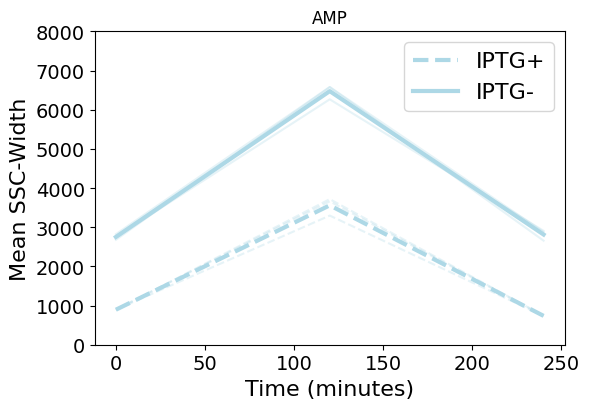

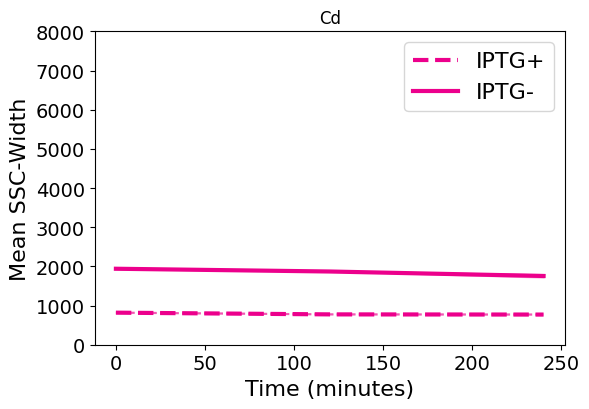

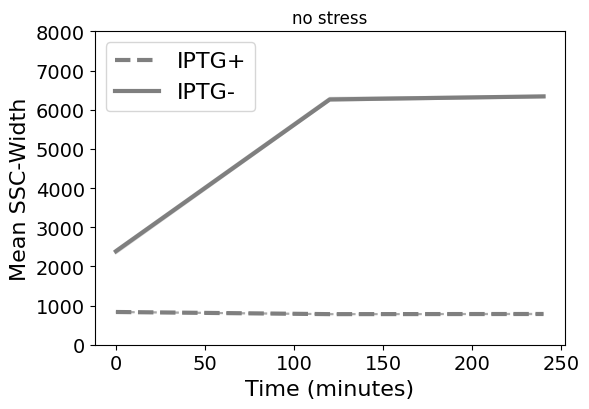

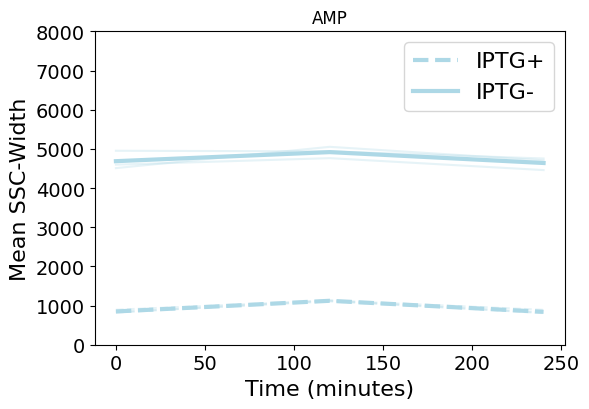

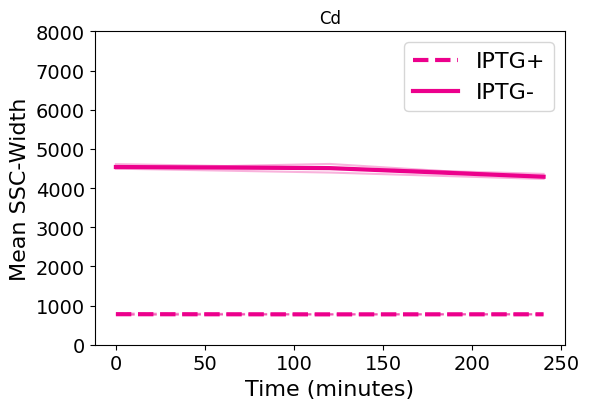

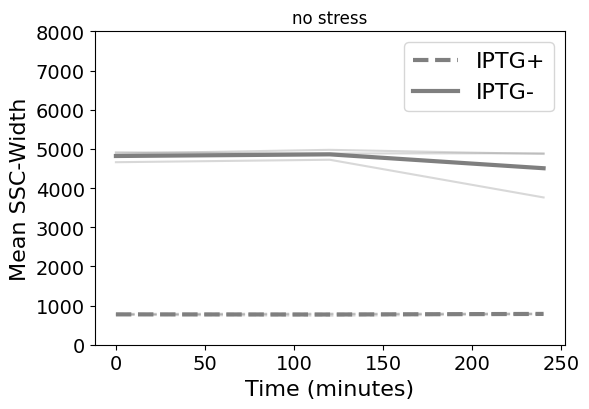

In [13]:

def plot_time_vs_ssc_width(df, this_strain, stress_condition):
    """
    Plots the mean SSC-Width (proxy for filamentation) over time for a given stress condition.

    Parameters:
    - df (pd.DataFrame): DataFrame with columns 'strain', 'stress', 'IPTG', 'time', 'rep', 'SSC-Width'.
    - this_strain (str): Strain to filter (e.g., 'VIP205').
    - stress_condition (str): Stress condition to filter (e.g., 'AMP', 'Cd', 'no stress').
    """
    # Filter for strain and stress condition
    df_strain = df[df['strain'] == this_strain].copy()
    df_exp = df_strain[df_strain['stress'] == stress_condition].copy()
    df_exp['time'] = df_exp['time'].astype(int)

    # Compute mean SSC-Width per time, IPTG, and replicate
    df_ssc_mean = (
        df_exp.groupby(['time', 'stress', 'IPTG', 'rep'])['SSC-Width']
        .mean()
        .reset_index(name='mean_SSC_Width')
    )


    # Dynamic color palette
    if stress_condition == "AMP":
        palette = {'IPTG+': '#ADD8E6', 'IPTG-': '#ADD8E6'}
    elif stress_condition == "Cd":
        palette = {'IPTG+': '#EC008C', 'IPTG-': '#EC008C'}
    else:
        palette = {'IPTG+': 'tab:grey', 'IPTG-': 'tab:grey'}

    # Plot setup
    plt.figure(figsize=(6, 4.2))

    # Plot individual replicates
    for (state, rep), subset in df_ssc_mean.groupby(['IPTG', 'rep']):
        linestyle = "--" if state == "IPTG+" else "-"
        sns.lineplot(data=subset, x="time", y="mean_SSC_Width",
                     color=palette.get(state, 'tab:blue'), linestyle=linestyle, alpha=0.3)

    # Compute and plot mean across replicates
    df_ssc_overall_mean = (
        df_ssc_mean.groupby(['time', 'IPTG'])['mean_SSC_Width']
        .mean()
        .reset_index()
    )
    for state in df_ssc_overall_mean['IPTG'].unique():
        subset = df_ssc_overall_mean[df_ssc_overall_mean['IPTG'] == state]
        linestyle = "--" if state == "IPTG+" else "-"
        sns.lineplot(data=subset, x="time", y="mean_SSC_Width",
                     color=palette.get(state, 'tab:blue'), linestyle=linestyle, linewidth=3, label=state)

    # Labeling
    plt.xlabel("Time (minutes)", fontsize=16)
    plt.ylabel("Mean SSC-Width", fontsize=16)
    plt.ylim(0, 8000)
    plt.title(stress_condition)
    plt.legend(fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()


plot_time_vs_ssc_width(df_combined, 'VIP205', 'AMP')
plot_time_vs_ssc_width(df_combined, 'VIP205', 'Cd')
plot_time_vs_ssc_width(df_combined, 'VIP205', 'no stress')

plot_time_vs_ssc_width(df_combined, 'VIPdeltaRecA', 'AMP')
plot_time_vs_ssc_width(df_combined, 'VIPdeltaRecA', 'Cd')
plot_time_vs_ssc_width(df_combined, 'VIPdeltaRecA', 'no stress')


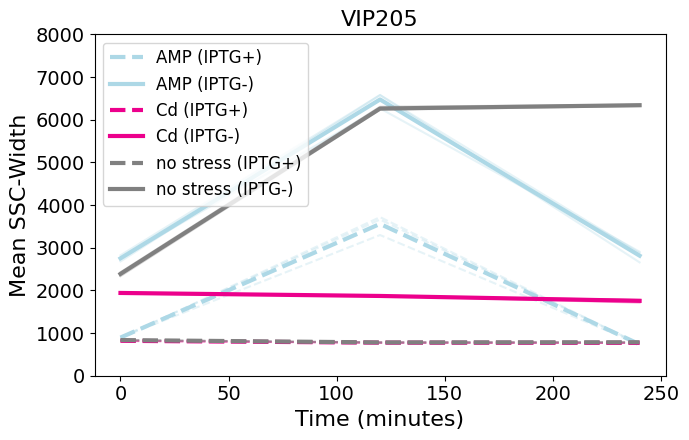

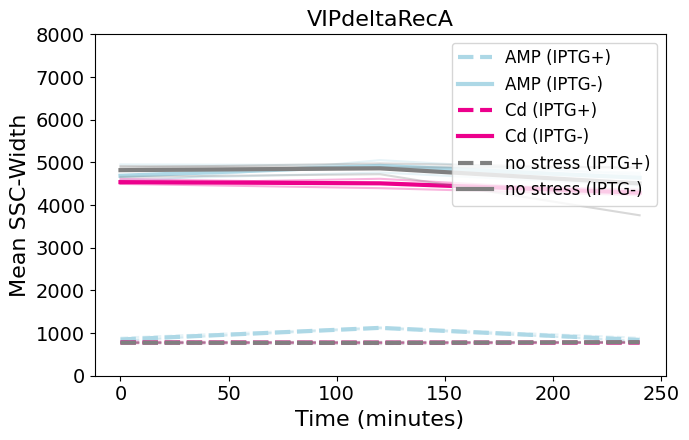

In [14]:
def plot_combined_ssc_width(df, this_strain, stress_conditions):
    """
    Plots mean SSC-Width (proxy for filamentation) over time for multiple stress conditions,
    including replicate-level curves and group means.

    Parameters:
    - df (pd.DataFrame): DataFrame with columns 'strain', 'stress', 'IPTG', 'time', 'rep', 'SSC-Width'.
    - this_strain (str): Strain to filter (e.g., 'VIP205').
    - stress_conditions (list of str): List of stress conditions (e.g., ['AMP', 'Cd', 'no stress']).
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Filter by strain and convert time to int
    df_strain = df[df['strain'] == this_strain].copy()
    df_strain['time'] = df_strain['time'].astype(int)

    # Define stress-specific color palette for IPTG-

    base_palette = {
        'AMP': '#ADD8E6',
        'Cd': '#EC008C',
        'no stress': 'grey'
    }

    plt.figure(figsize=(7, 4.5))

    for stress in stress_conditions:
        df_exp = df_strain[df_strain['stress'] == stress].copy()

        # Mean per replicate
        df_ssc_mean = (
            df_exp.groupby(['time', 'IPTG', 'rep'])['SSC-Width']
            .mean()
            .reset_index(name='mean_SSC_Width')
        )

        # Plot individual replicates
        for (iptg, rep), subrep in df_ssc_mean.groupby(['IPTG', 'rep']):
            linestyle = "--" if iptg == "IPTG+" else "-"
            color = base_palette.get(stress, 'tab:black') if iptg == 'IPTG+' else base_palette.get(stress, 'tab:black')
            sns.lineplot(data=subrep, x="time", y="mean_SSC_Width",
                         color=color, linestyle=linestyle, alpha=0.3)

        # Plot group mean
        df_ssc_overall_mean = (
            df_ssc_mean.groupby(['time', 'IPTG'])['mean_SSC_Width']
            .mean()
            .reset_index()
        )
        for iptg in ['IPTG+', 'IPTG-']:
            subset = df_ssc_overall_mean[df_ssc_overall_mean['IPTG'] == iptg]
            linestyle = "--" if iptg == "IPTG+" else "-"
            color = base_palette.get(stress, 'tab:black') if iptg == 'IPTG+' else base_palette.get(stress, 'tab:black')
            label = f"{stress} ({iptg})"
            sns.lineplot(data=subset, x="time", y="mean_SSC_Width",
                         color=color, linestyle=linestyle, linewidth=3, label=label)

    # Labeling
    plt.xlabel("Time (minutes)", fontsize=16)
    plt.ylabel("Mean SSC-Width", fontsize=16)
    plt.ylim(0, 8000)
    plt.title(this_strain, fontsize=16)
    plt.legend(fontsize=12)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()

plot_combined_ssc_width(df_combined, 'VIP205', ['AMP', 'Cd', 'no stress'])
plot_combined_ssc_width(df_combined, 'VIPdeltaRecA', ['AMP', 'Cd', 'no stress'])


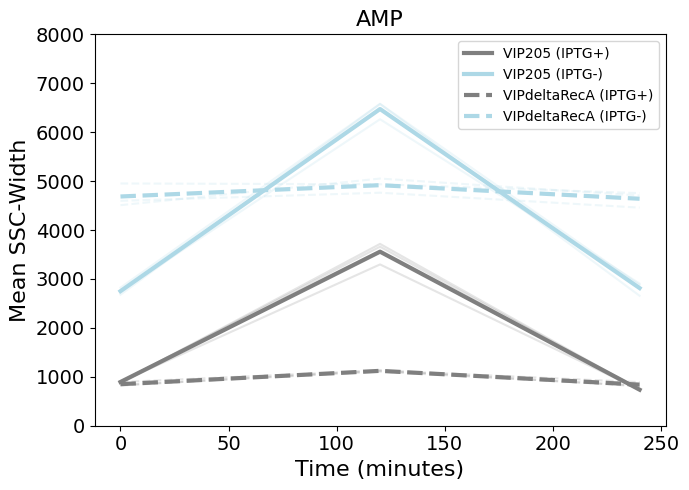

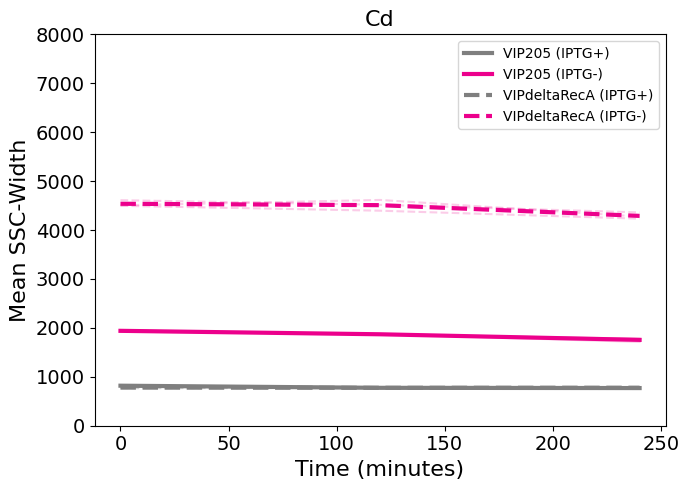

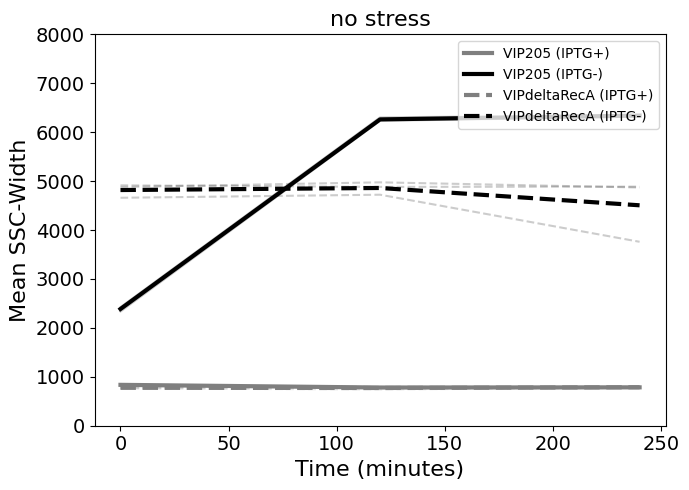

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_ssc_width_by_stress(df, strains, stress_conditions):
    """
    Plots mean SSC-Width over time for each stress condition, comparing strains and IPTG status.
    - Colors represent the stress condition.
    - Line style represents the strain (solid for VIP205, dashed for delta strains).
    - Grey is always used for IPTG+ (control).
    - IPTG- lines use stress-specific colors.
    """
    df = df.copy()
    df['time'] = df['time'].astype(int)

    # Define stress-specific colors
    stress_colors = {
        'AMP': '#ADD8E6',      # Light blue
        'Cd': '#EC008C',       # Magenta
        'no stress': 'black'
    }

    for stress in stress_conditions:
        plt.figure(figsize=(7, 5))
        for strain in strains:
            df_exp = df[(df['strain'] == strain) & (df['stress'] == stress)].copy()

            # Compute mean SSC-Width per time, IPTG, and replicate
            df_ssc_mean = (
                df_exp.groupby(['time', 'IPTG', 'rep'])['SSC-Width']
                .mean()
                .reset_index(name='mean_SSC_Width')
            )

            # Replicate lines
            for (iptg, rep), subrep in df_ssc_mean.groupby(['IPTG', 'rep']):
                linestyle = '--' if 'delta' in strain else '-'
                color = 'tab:grey' if iptg == 'IPTG+' else stress_colors.get(stress, 'tab:blue')
                sns.lineplot(data=subrep, x='time', y='mean_SSC_Width',
                             color=color, linestyle=linestyle, alpha=0.2)

            # Mean lines
            df_mean = (
                df_ssc_mean.groupby(['time', 'IPTG'])['mean_SSC_Width']
                .mean()
                .reset_index()
            )
            for iptg in df_mean['IPTG'].unique():
                subset = df_mean[df_mean['IPTG'] == iptg]
                linestyle = '--' if 'delta' in strain else '-'
                color = 'tab:grey' if iptg == 'IPTG+' else stress_colors.get(stress, 'tab:blue')
                label = f"{strain} ({iptg})"
                sns.lineplot(data=subset, x='time', y='mean_SSC_Width',
                             color=color, linestyle=linestyle, linewidth=3, label=label)

        # Labels and formatting
        plt.xlabel("Time (minutes)", fontsize=16)
        plt.ylabel("Mean SSC-Width", fontsize=16)
        plt.title(stress, fontsize=16)
        plt.ylim(0, 8000)
        plt.legend(fontsize=10, loc='upper right')
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.tight_layout()
        plt.show()

plot_ssc_width_by_stress(
    df_combined,
    strains=['VIP205', 'VIPdeltaRecA'],
    stress_conditions=['AMP']
)


plot_ssc_width_by_stress(
    df_combined,
    strains=['VIP205', 'VIPdeltaRecA'],
    stress_conditions=['Cd']
)



plot_ssc_width_by_stress(
    df_combined,
    strains=['VIP205', 'VIPdeltaRecA'],
    stress_conditions=['no stress']
)


### Filamentation fraction

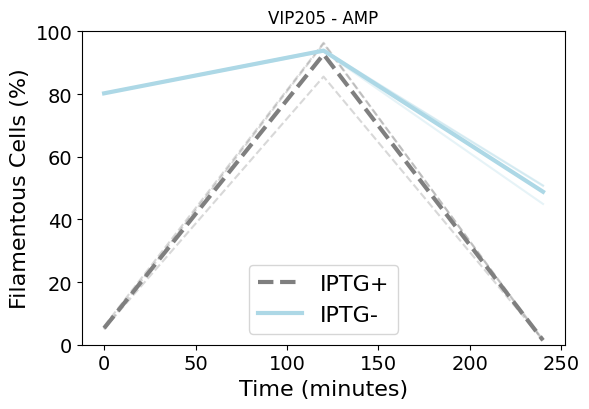

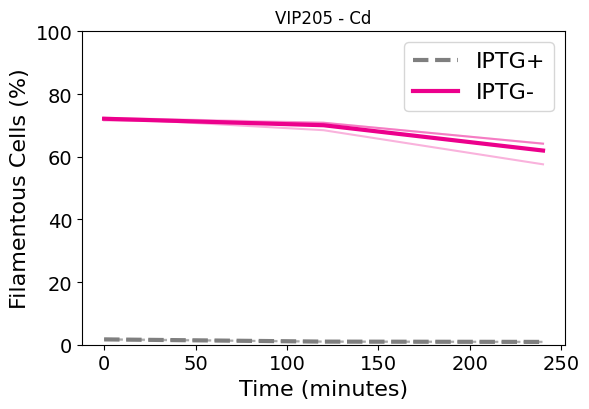

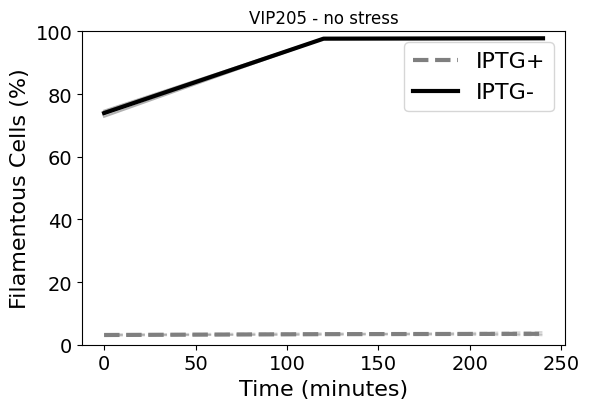

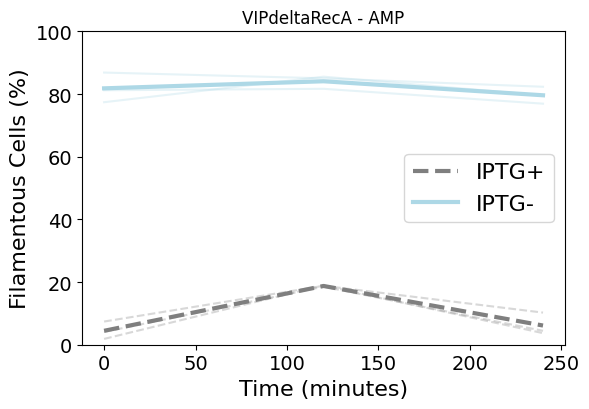

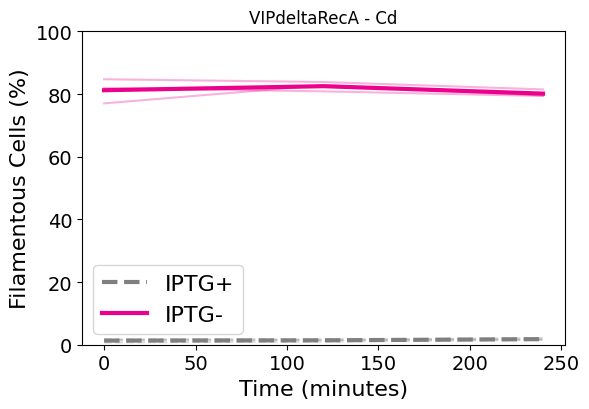

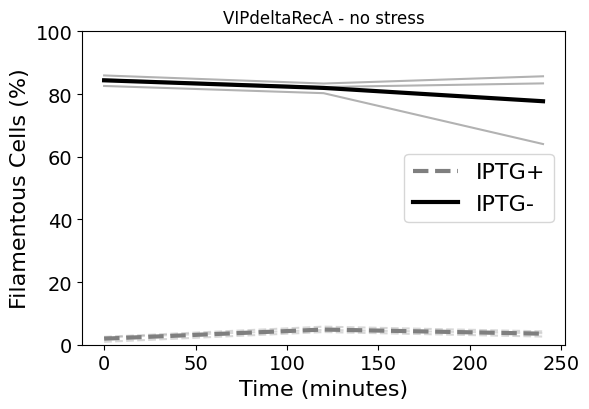

In [16]:

def plot_filamentous_fraction(df, this_strain, stress_condition):
    """
    Plots the percentage of filamentous cells (size != 'normal') over time for a given stress condition.

    Parameters:
    - df (pd.DataFrame): DataFrame with columns 'strain', 'stress', 'IPTG', 'time', 'rep', 'size'.
    - this_strain (str): Strain to filter (e.g., 'VIP205').
    - stress_condition (str): Stress condition to filter (e.g., 'AMP', 'Cd', 'no stress').
    """
    # Filter for the selected strain and stress condition
    df_strain = df[df['strain'] == this_strain].copy()
    df_exp = df_strain[df_strain['stress'] == stress_condition].copy()
    df_exp['time'] = df_exp['time'].astype(int)

    # Compute the fraction of filamentous cells per time, IPTG, and replicate
    df_fil_fraction = (
        df_exp.groupby(['time', 'stress', 'IPTG', 'rep'])['size']
        .apply(lambda x: (x != 'normal').mean())
        .reset_index(name='filamentous_fraction')
    )

    # Convert fraction to percentage
    df_fil_fraction['filamentous_fraction'] *= 100

    # Dynamic color palette based on stress condition
    if stress_condition == "AMP":
        palette = {'IPTG+': 'tab:grey', 'IPTG-': '#ADD8E6'}
    elif stress_condition == "Cd":
        palette = {'IPTG+': 'tab:grey', 'IPTG-': '#EC008C'}
    else:
        palette = {'IPTG+': 'tab:grey', 'IPTG-': 'black'}

    # Plot setup
    plt.figure(figsize=(6, 4.2))

    # Plot individual replicates
    for (state, rep), subset in df_fil_fraction.groupby(['IPTG', 'rep']):
        linestyle = "--" if state == "IPTG+" else "-"
        sns.lineplot(data=subset, x="time", y="filamentous_fraction",
                     color=palette.get(state, 'tab:blue'), linestyle=linestyle, alpha=0.3)

    # Compute and plot mean over replicates
    df_fil_mean = (
        df_fil_fraction.groupby(['time', 'IPTG'])['filamentous_fraction']
        .mean()
        .reset_index()
    )
    for state in df_fil_mean['IPTG'].unique():
        subset = df_fil_mean[df_fil_mean['IPTG'] == state]
        linestyle = "--" if state == "IPTG+" else "-"
        sns.lineplot(data=subset, x="time", y="filamentous_fraction",
                     color=palette.get(state, 'tab:blue'), linestyle=linestyle, linewidth=3, label=state)

    # Labeling
    plt.xlabel("Time (minutes)", fontsize=16)
    plt.ylabel("Filamentous Cells (%)", fontsize=16)
    plt.title(f"{this_strain} - {stress_condition}")
    plt.legend(fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.ylim([0, 100])
    plt.tight_layout()
    plt.show()


plot_filamentous_fraction(df_combined, 'VIP205', 'AMP')
plot_filamentous_fraction(df_combined, 'VIP205', 'Cd')
plot_filamentous_fraction(df_combined, 'VIP205', 'no stress')

plot_filamentous_fraction(df_combined, 'VIPdeltaRecA', 'AMP')
plot_filamentous_fraction(df_combined, 'VIPdeltaRecA', 'Cd')
plot_filamentous_fraction(df_combined, 'VIPdeltaRecA', 'no stress')


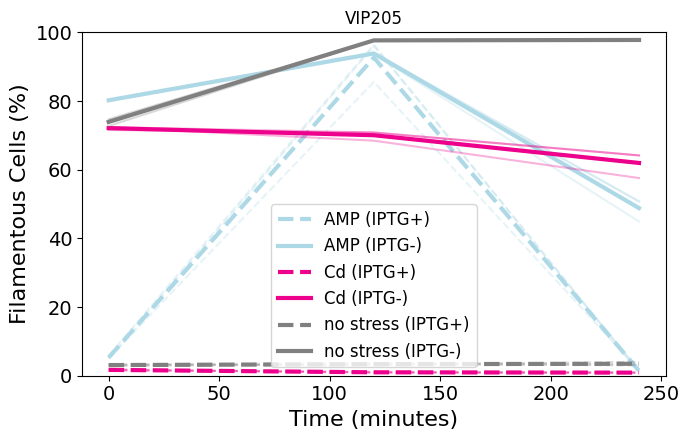

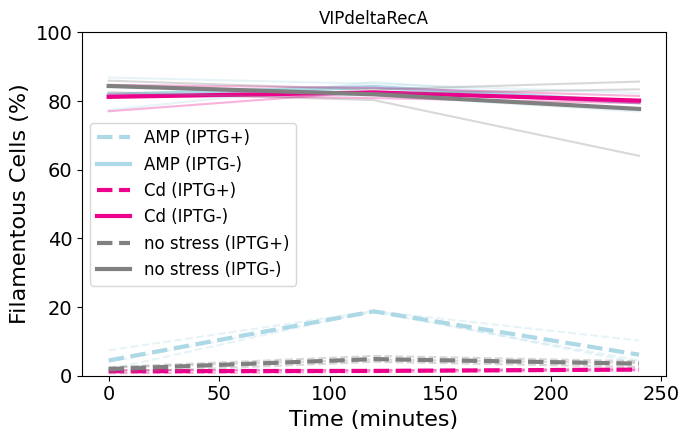

In [17]:
def plot_combined_filamentous_fraction(df, this_strain, stress_conditions):
    """
    Plots the percentage of filamentous cells (size != 'normal') over time for multiple stress conditions.

    Parameters:
    - df (pd.DataFrame): DataFrame with columns 'strain', 'stress', 'IPTG', 'time', 'rep', 'size'.
    - this_strain (str): Strain to filter (e.g., 'VIP205').
    - stress_conditions (list): List of stress conditions (e.g., ['AMP', 'Cd', 'no stress']).
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Filter by strain
    df_strain = df[df['strain'] == this_strain].copy()
    df_strain['time'] = df_strain['time'].astype(int)

    # Stress-specific color palette for IPTG-

    base_palette = {
        'AMP': '#ADD8E6',
        'Cd': '#EC008C',
        'no stress': 'grey'
    }


    plt.figure(figsize=(7, 4.5))

    for stress in stress_conditions:
        df_exp = df_strain[df_strain['stress'] == stress].copy()

        # Compute filamentous fraction per time, IPTG, and replicate
        df_fil_fraction = (
            df_exp.groupby(['time', 'IPTG', 'rep'])['size']
            .apply(lambda x: (x != 'normal').mean())
            .reset_index(name='filamentous_fraction')
        )
        df_fil_fraction['filamentous_fraction'] *= 100

        # Plot individual replicates
        for (iptg, rep), subset in df_fil_fraction.groupby(['IPTG', 'rep']):
            linestyle = "--" if iptg == "IPTG+" else "-"
            color = base_palette.get(stress, 'tab:black') if iptg == 'IPTG+' else base_palette.get(stress, 'tab:black')
            sns.lineplot(data=subset, x="time", y="filamentous_fraction",
                         color=color, linestyle=linestyle, alpha=0.3)

        # Plot mean across replicates
        df_fil_mean = (
            df_fil_fraction.groupby(['time', 'IPTG'])['filamentous_fraction']
            .mean()
            .reset_index()
        )
        for iptg in ['IPTG+', 'IPTG-']:
            subset = df_fil_mean[df_fil_mean['IPTG'] == iptg]
            linestyle = "--" if iptg == "IPTG+" else "-"
            color = base_palette.get(stress, 'tab:black') if iptg == 'IPTG+' else base_palette.get(stress, 'tab:black')
            label = f"{stress} ({iptg})"
            sns.lineplot(data=subset, x="time", y="filamentous_fraction",
                         color=color, linestyle=linestyle, linewidth=3, label=label)

    # Labeling
    plt.xlabel("Time (minutes)", fontsize=16)
    plt.ylabel("Filamentous Cells (%)", fontsize=16)
    plt.title(this_strain)
    plt.legend(fontsize=12)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.ylim([0, 100])
    plt.tight_layout()
    plt.show()

plot_combined_filamentous_fraction(df_combined, 'VIP205', ['AMP', 'Cd', 'no stress'])
plot_combined_filamentous_fraction(df_combined, 'VIPdeltaRecA', ['AMP', 'Cd', 'no stress'])


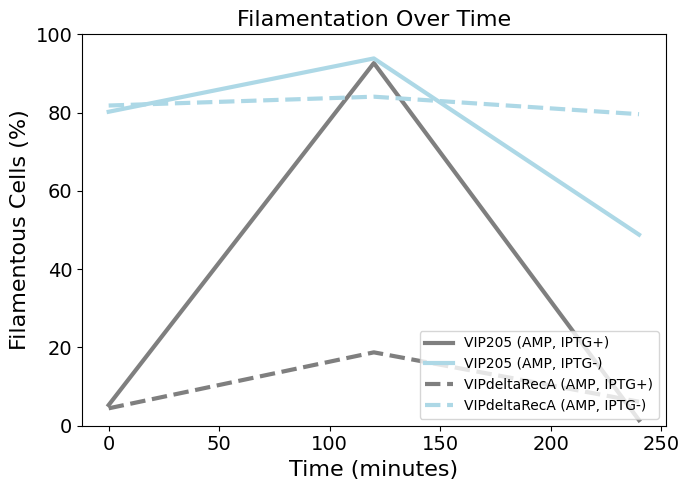

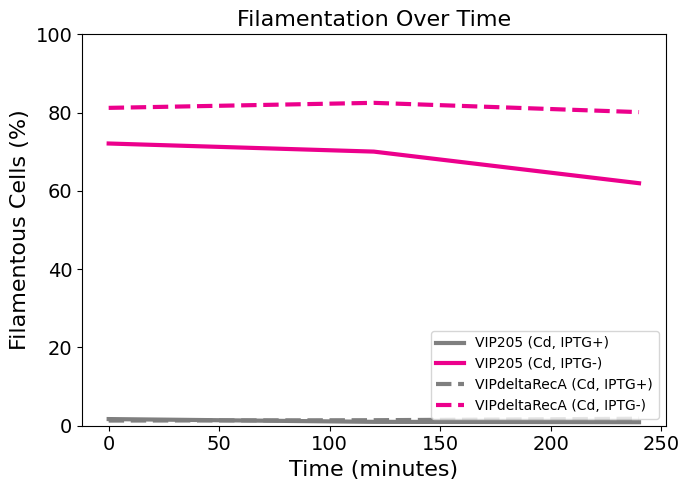

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_filamentation_all_strains(df, strains, stress_conditions):
    """
    Plots % filamentous cells over time for multiple strains and stress conditions.

    Parameters:
    - df (pd.DataFrame): DataFrame with columns 'strain', 'stress', 'IPTG', 'time', 'rep', 'size'.
    - strains (list): List of strains to include (e.g., ['VIP205', 'VIPdeltaRecA']).
    - stress_conditions (list): List of stress conditions (e.g., ['AMP', 'Cd', 'no stress']).
    """
    df = df.copy()
    df['time'] = df['time'].astype(int)

    # Define stress-specific colors for IPTG-
    stress_colors = {
        'AMP': '#ADD8E6',       # light blue
        'Cd': '#EC008C',        # magenta
        'no stress': 'black'
    }

    plt.figure(figsize=(7, 5))

    for stress in stress_conditions:
        for strain in strains:
            df_subset = df[(df['strain'] == strain) & (df['stress'] == stress)].copy()

            # Compute filamentous % per time, IPTG, and rep
            df_fil = (
                df_subset.groupby(['time', 'IPTG', 'rep'])['size']
                .apply(lambda x: (x != 'normal').mean())
                .reset_index(name='filamentous_fraction')
            )
            df_fil['filamentous_fraction'] *= 100

            # Mean across replicates
            df_mean = df_fil.groupby(['time', 'IPTG'])['filamentous_fraction'].mean().reset_index()

            for iptg in df_mean['IPTG'].unique():
                subset = df_mean[df_mean['IPTG'] == iptg]

                # Color scheme
                color = 'tab:grey' if iptg == 'IPTG+' else stress_colors.get(stress, 'tab:black')

                # Line style: dashed if 'delta' in strain
                linestyle = '--' if 'delta' in strain else '-'

                # Label
                label = f"{strain} ({stress}, {iptg})"

                sns.lineplot(
                    data=subset, x='time', y='filamentous_fraction',
                    color=color, linestyle=linestyle, linewidth=3, label=label
                )

    # Plot formatting
    plt.xlabel("Time (minutes)", fontsize=16)
    plt.ylabel("Filamentous Cells (%)", fontsize=16)
    plt.ylim([0, 100])
    plt.title("Filamentation Over Time", fontsize=16)
    plt.legend(fontsize=10, loc='lower right')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()

plot_filamentation_all_strains(
    df_combined,
    strains=['VIP205', 'VIPdeltaRecA'],
    stress_conditions=['AMP']
)



plot_filamentation_all_strains(
    df_combined,
    strains=['VIP205', 'VIPdeltaRecA'],
    stress_conditions=['Cd']
)



=== Survival Stats for VIP205 under AMP at 240 min ===

IPTG- - Mann-Whitney U:
  Survived (n=11430): 4720.08 ± 2464.46
  Died     (n=17513): 1568.50 ± 1551.99
  U-stat = 158542385.5, p = 0.0

IPTG+ - Mann-Whitney U:
  Survived (n=4661): 737.83 ± 324.00
  Died     (n=24004): 736.22 ± 156.11
  U-stat = 51415506.5, p = 2.0533427071733504e-18



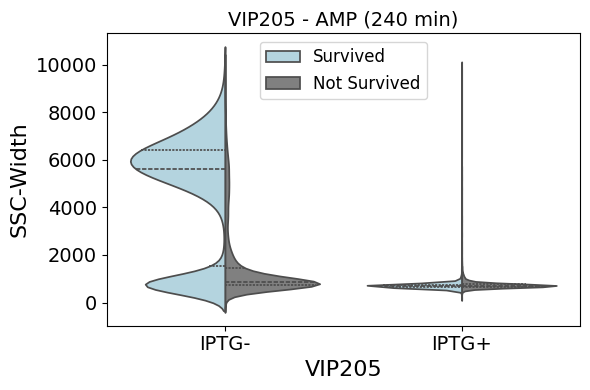


=== Survival Stats for VIP205 under Cd at 240 min ===

IPTG- - Mann-Whitney U:
  Survived (n=19202): 2036.79 ± 979.89
  Died     (n=10351): 1231.46 ± 680.49
  U-stat = 154716205.0, p = 0.0

IPTG+ - Mann-Whitney U:
  Survived (n=10140): 819.94 ± 137.66
  Died     (n=17102): 739.93 ± 118.07
  U-stat = 131199015.0, p = 0.0



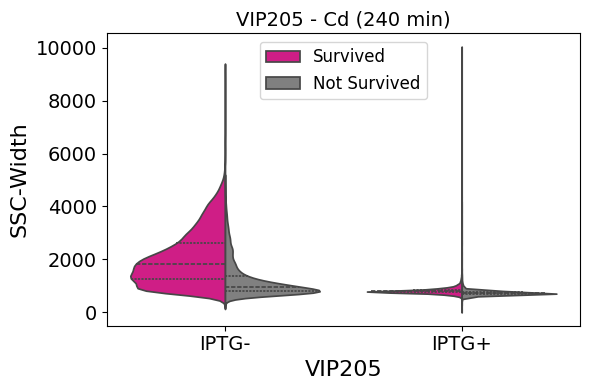


=== Survival Stats for VIPdeltaRecA under AMP at 240 min ===

IPTG- - Mann-Whitney U:
  Survived (n=25835): 5015.15 ± 2212.70
  Died     (n=3186): 1592.10 ± 1595.35
  U-stat = 70674505.0, p = 0.0

IPTG+ - Mann-Whitney U:
  Survived (n=11805): 847.78 ± 348.52
  Died     (n=11092): 833.22 ± 248.41
  U-stat = 63620960.0, p = 0.00021543411881633996



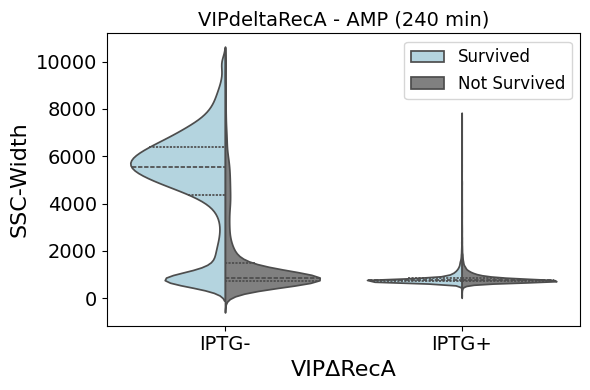


=== Survival Stats for VIPdeltaRecA under Cd at 240 min ===

IPTG- - Mann-Whitney U:
  Survived (n=26202): 4474.55 ± 2084.88
  Died     (n=2702): 2493.23 ± 2298.34
  U-stat = 52191750.0, p = 0.0

IPTG+ - Mann-Whitney U:
  Survived (n=12227): 770.65 ± 163.85
  Died     (n=11273): 783.69 ± 151.72
  U-stat = 66201876.0, p = 1.7247899131426935e-07



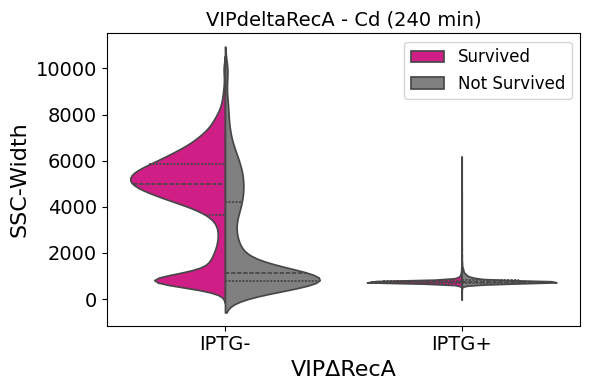

In [19]:


def plot_survival_vs_non_survival_log(df, this_strain, stress_condition, timepoint, pixel2um=1):
    """
    Generate a violin plot comparing SSC-Width distributions for survived vs. non-survived cells,
    filtered by strain, stress, and timepoint. Y-axis is in log scale.

    Parameters:
    - df (pd.DataFrame): Combined dataset with columns ['strain', 'stress', 'IPTG', 'state', 'SSC-Width']
    - this_strain (str): Strain name (e.g., 'VIP205')
    - stress_condition (str): Stress name (e.g., 'AMP', 'Cd')
    - timepoint (int): Time (in minutes) to filter the data (e.g., 120, 240)
    - pixel2um (float): Conversion factor from pixel to micrometer
    """
    # Set color based on stress condition
    if stress_condition == "AMP":
        survived_color = "#ADD8E6"
    elif stress_condition == "Cd":
        survived_color = "#EC008C"
    else:
        survived_color = "black"

    # Filter dataframe
    df_filtered = df[
        (df['strain'] == this_strain) &
        (df['stress'] == stress_condition) &
        (df['time'] == timepoint)
    ].copy()

    if df_filtered.empty:
        print(f"⚠️ No data found for {this_strain} under {stress_condition} at time {timepoint} min.")
        return

    df_filtered['SSC-Width'] *= pixel2um

    states = ["IPTG-", "IPTG+"]
    labels = {"IPTG-": "IPTG-", "IPTG+": "IPTG+"}
    results = {}

    print(f"\n=== Survival Stats for {this_strain} under {stress_condition} at {timepoint} min ===\n")

    for state in states:
        subset = df_filtered[df_filtered['IPTG'] == state]
        survived = subset[subset['state'] == "alive"]['SSC-Width']
        non_survived = subset[subset['state'] == "dead"]['SSC-Width']

        mean_surv, std_surv = survived.mean(), survived.std()
        mean_dead, std_dead = non_survived.mean(), non_survived.std()

        if len(survived) > 0 and len(non_survived) > 0:
            stat, p = mannwhitneyu(survived, non_survived, alternative='two-sided', method='asymptotic')
        else:
            stat, p = None, None

        print(f"{labels[state]} - Mann-Whitney U:")
        print(f"  Survived (n={len(survived)}): {mean_surv:.2f} ± {std_surv:.2f}")
        print(f"  Died     (n={len(non_survived)}): {mean_dead:.2f} ± {std_dead:.2f}")
        print(f"  U-stat = {stat}, p = {p}\n")

        results[state] = (survived, non_survived)

    # Prepare data for plotting
    plot_data, group_labels, survival_labels = [], [], []
    for state in states:
        survived, non_survived = results[state]
        plot_data.extend(survived)
        group_labels.extend([labels[state]] * len(survived))
        survival_labels.extend(["Survived"] * len(survived))
        plot_data.extend(non_survived)
        group_labels.extend([labels[state]] * len(non_survived))
        survival_labels.extend(["Not Survived"] * len(non_survived))

    # Create violin plot
    plt.figure(figsize=(6, 4))
    sns.violinplot(
        x=group_labels,
        y=plot_data,
        hue=survival_labels,
        split=True,
        inner="quartile",
        palette={"Survived": survived_color, "Not Survived": "grey"},
        density_norm="width"
    )

    #plt.yscale("log")
    plt.xlabel(this_strain.replace('delta', 'Δ'), fontsize=16)
    plt.ylabel("SSC-Width", fontsize=16)
    plt.title(f"{this_strain} - {stress_condition} ({timepoint} min)", fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

this_time=240

plot_survival_vs_non_survival_log(df_combined, this_strain="VIP205", stress_condition="AMP", timepoint=this_time)
plot_survival_vs_non_survival_log(df_combined, this_strain="VIP205", stress_condition="Cd", timepoint=this_time)

plot_survival_vs_non_survival_log(df_combined, this_strain="VIPdeltaRecA", stress_condition="AMP", timepoint=this_time)
plot_survival_vs_non_survival_log(df_combined, this_strain="VIPdeltaRecA", stress_condition="Cd", timepoint=this_time)
